# Exploring Semantic Embeddings with NumPy and Matplotlib

This tutorial will provide an introduction to text embeddings and explore how they can be used with NumPy, Matplotlib, and the OpenAI API. 

* We will show how to encode text as a **semantic embedding** using the **OpenAI API**.
* We will learn to use the **NumPy linear albegra library** to calculate the **semantic similarity** between them. 
* We will learn to **visualize** the embeddings using **Matplotlib** along with **PCA** and **t-SNE**. 
* We will also find the **nearest neighbors** for purpose of **exploratory data analysis**, **classification**, and **recommendation**. 

By the end of this tutorial, you will have a better understanding of how semantic embeddings work and how to use NumPy and Matplotlib to work with them.

In [1]:
import numpy as np
from openai import OpenAI
import os
import pickle
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

## Text embeddings

In this experiment, we will the OpenAI API and NumPy to represent text as a **vector**.  

A vector is just a list of numbers that represents something.  In this case we have a list of numbers that represents a sequence of words.  For example, a vector that represents the phrase "the green elephant" might look like this:

```
[-0.0139, -0.015 ,  0.014 , -0.0121, -0.005 , -0.0062, -0.0227, -0.0211 ...
```

This turns out to be the first part of a long vector obtained with OpenAI's `text-embedding-ada-002` model. It contains 1536 floating point numerals.

The list of numbers that represents the phrase is not in any particular order.  The numbers are stored in a list or NumPy array so that they can be used later to do calculations.

### OpenAI API 

To use OpenAI to create semantic embeddings, you need to create an account and a key. The cost of creating the embeddings depends on the number of tokens in the text sent to their server. The code below specifies the path on my local machine where my private key is located.

In [2]:
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
print(client)

In [3]:
# to display the full distance matrix later in this tutorial
np.set_printoptions(linewidth=150)

In [4]:
# Source: OpenAI official site
# URL: https://platform.openai.com/docs/guides/embeddings
def get_embedding(text, model="text-embedding-ada-002"):
    text = text.replace("\n", " ")
    response = client.embeddings.create(
        model=model,
        input=text,
        encoding_format="float"
    )
    return response.data[0].embedding

In [5]:
np.array(get_embedding("The green elephant"))

array([-0.01121562, -0.01367322,  0.02091198, ..., -0.01839693, -0.00284699, -0.02984873], shape=(1536,))

### Food embeddings as an example

Let's experiment with embeddings by using food words as an example. 

In [6]:
foods = ["Spaghetti",
         "Hoppin' john",
         "Ratatouille",
         "Eggplant parmesan",
         "Jambalaya",
         "Falafel",
         "Tofu stir fry",
         "Steel cut oats",
         "Blueberries",
         "Mixed nuts",
         "PBJ sandwich",
         "Hot dog",
         "Coke Zero",
         "Bourbon",
         "Evian water",
         "Cheetos",
         "Shrimp etouffee"]

### Encoding the strings

This code is used to embed a list of foods into a single numpy matrix. Each row of the matrix contains a text embedding of one of the foods listed above. The 1536 columns correspond to the dimensions of the embedding.

In [7]:
def embed_foods():
    '''
    Embeds a list of foods into a single numpy matrix.
    '''
    embedding_size = 1536
    x = np.zeros((len(foods), embedding_size))
    for i, food in enumerate(foods):
        x[i,:] = get_embedding(food)
    return x

### Saving our computations between sessions

In Python we can save our variables between sessions by using Pickle. Pickle allows us to save variables in a file and load them into our program when we need them. This is useful if we have a long list of foods that we need to compute semantic distances between.

The code below checks if a Pickle file exists and loads it. If it does not exist, it prompts the user to rerun the code that creates it. 

In [8]:
embeddings_file = 'food_embeddings.pickle'
try: # throws exception if pickle file does not exist
    with open(embeddings_file, 'rb') as f:
        x = pickle.load(f) 
except FileNotFoundError:
    print("Pickle file not found. Would you like to rerun the code that creates it?")
    answer = input("Entering 'yes' will recompute all food embeddings. Continue? (yes/no) ")
    if answer == "yes":
        x = embed_foods()
        with open(embeddings_file, 'wb') as f:
            pickle.dump(x, f)
finally:
    print('x =')
    print(x)

x =
[[ 0.00293508 -0.00416984  0.0058764  ... -0.00026684 -0.00579543 -0.01035765]
 [-0.0044604   0.00502312  0.00125101 ... -0.03698034  0.00763006  0.00500722]
 [-0.00715851  0.00169124  0.00154055 ... -0.00350742 -0.01038796 -0.01734034]
 ...
 [ 0.01311829 -0.01722803 -0.00770001 ... -0.02294878 -0.01781983 -0.0073252 ]
 [-0.0110408  -0.01000771  0.00879715 ...  0.00694011  0.01688444 -0.01408304]
 [ 0.00866439 -0.00536565 -0.00204931 ... -0.02325436  0.00176615  0.00270362]]


We can use the `.shape` property to get the size of our numpy matrix. We discover that it is 17 rows and 1536 columns. There is one row for each string of text and one column for each dimension of the embedding.

In [9]:
x.shape

(17, 1536)

### Dot product

Once we have computed the semantic embeddings of a set of phrases, we can estimate how similar they are to one another with a simple mathematical calculation known as a **dot product**. This section explains how the math works for those who have not taken a course in linear algebra.

To compute the dot product, we multiply the corresponding entries of two vectors and add the products together to get a single number. 

$$\mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^{n} u_i v_i $$

For example, suppose we had two vectors. For example, if we had two vectors, u and v, that looked like this:

```
u = [ 3.0 4.0]
v = [11.0 0.0]
```

we would multiply the first element of u with the first element of v and add that result to the product of the second element of u with the second element of v, and so on, if there were other elements. The result would be:

```
3.0 * 11.0 + 4.0 * 0.0 = 33.0 + 0.0 = 33.0.
```

In this case, our dot product would be 33.


### Normalization

Another thing you can do with a vector is **normalize** it.  This means that you **scale** the vector so that its length is 1. Another way to think of this is that we change the numbers in the vector so that their squares add up to 1.  We can do this by dividing each element in the vector by its length.

To compute its length, we can use the **Pythagorean theorem**. This states that the length of a vector is the square root of the sum of the squares of its elements. For example, the length of vector u and v is:

$$ \|u\| = \sqrt{u\cdot u} = \sqrt{3^2 + 4^2} = \sqrt{25} = 5$$

Now we can divide each element in the vector by its length to get a normalized vector:

$$ \hat{u} = \frac{u}{\|u\|} $$

In this case:

```
3.0 / 5.0 = 0.6
4.0 / 5.0 = 0.8
```

Now we have a normalized vector.

```
u = [0.6 0.8]
```

A **unit vector** is a vector with a length of 1. Thus, if $u\cdot u=1$, $u$ is a unit vector. Returning to our dataset, we can confirm that all of the vectors are unit vectors since they have length 1 (up to machine precision limits).

In [10]:
np.round(x[10] @ x[10], 6)

np.float64(1.0)

In [11]:
np.all(np.abs(1. - np.sum(x * x, axis=1)) < 1e-06)

np.True_

In [12]:
np.max(np.abs(1. - np.sum(x * x, axis=1)))

np.float64(1.7792194029198072e-07)

### Angle

The angle between two vectors is a measure of how similar they are.  The more similar the two vectors are, the smaller the angle.  

The angle between two vectors can be computed from their dot product. An important identity in linear algebra states that the dot product of two normalized vectors is equal to the cosine of the angle between them. 

$$\cos \theta = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$$

In our case, since our vectors all have length 1, this simplifies to:

$$\cos \theta = \mathbf{\hat{u}} \cdot \mathbf{\hat{v}}$$

For our example, we would have:

In [13]:
u = np.array([3, 4])
v = np.array([11, 0])
u = u / np.sqrt(u @ u) # compute norm of u and v
v = v / np.sqrt(v @ v) # in numpy dot product is @ or .dot()

In [14]:
print('u =', u, '\tv =', v, '\tu . v =', u @ v)
radians = np.arccos(u @ v)
print(f'theta = {radians:.3f} radians = {np.degrees(radians):.1f} degrees')

u = [0.6 0.8] 	v = [1. 0.] 	u . v = 0.6
theta = 0.927 radians = 53.1 degrees


For the two unit vectors in our example, $\hat{u}$ and $\hat{v}$, the dot product is equal to $0.6$. This means the angle between our two vectors is $\theta = \arccos(0.6) \approx 53.1^\circ$. 

**However, if we only wish to compare two vectors, it is not necessary to compute the cosine inverse. Instead, we can just use the dot product as a measure of similarity.** The **more similar** two vectors are, **the larger the dot product** and the **smaller the angle** between them. If the two points on the unit hypersphere are identical, the angle is 0 and the dot product is 1. As the angle increases, the dot product decreases to -1. A special case, a right angle, has a dot product of 0, indicating the two vectors are **orthogonal**. In general, the dot product of two unit vectors will always be in the range $[-1, 1]$.

Therefore, we define the **cosine similarity** as:

$$ \text{cosine similarity} = \cos \theta = \frac{u \cdot v}{\|u\| \|v\|} $$

Analagously, we can define the **cosine distance** as:

$$ \text{cosine distance} = 1 -  \text{cosine similarity} =  1 - \frac{u \cdot v}{\|u\| \|v\|}$$ 

This measures the dissimilarity between two vectors and is in the range $[0,2]$.

### Semantic Distance with NumPy

We now use NumPy to estimate the semantic distance between a list of phrases. 

* First, we call the OpenAI text embeddings API to create embeddings for the list of phrases. 
* We then store the embeddings in a numpy matrix, `x`. 
* Finally, we calculate the semantic distance between the phrases by performing matrix multiplication between $\mathbf{X}$ and its transpose, $\mathbf{X}^{\top}$. 

**Matrix multiplication** $\mathbf{AB}$ computes the dot products for every combination of **row** from $\mathbf{A}$ and **column** of $\mathbf{B}$. In this case, our matrix $\mathbf{X}$ is a matrix of embeddings, and its transpose $\mathbf{X}^{\top}$ is a matrix of the same embeddings, except with the rows and columns reversed. The result of the matrix multiplication is a matrix $\mathbf{XX}^{\top}$ containing the dot product of each pair of embeddings, giving us the similarity between each pair of foods. We call this matrix a **similarity matrix** because it contains the semantic similarity between each instance in our dataset.

In [15]:
similarity_matrix = np.round(x @ x.T, 2)
similarity_matrix

array([[1.  , 0.8 , 0.84, 0.86, 0.84, 0.85, 0.84, 0.77, 0.81, 0.81, 0.81, 0.84, 0.78, 0.81, 0.76, 0.84, 0.83],
       [0.8 , 1.  , 0.78, 0.79, 0.84, 0.79, 0.79, 0.79, 0.81, 0.78, 0.82, 0.8 , 0.77, 0.79, 0.76, 0.79, 0.81],
       [0.84, 0.78, 1.  , 0.85, 0.82, 0.85, 0.82, 0.75, 0.78, 0.77, 0.77, 0.81, 0.76, 0.8 , 0.77, 0.79, 0.84],
       [0.86, 0.79, 0.85, 1.  , 0.83, 0.85, 0.84, 0.77, 0.8 , 0.8 , 0.81, 0.8 , 0.76, 0.77, 0.75, 0.8 , 0.83],
       [0.84, 0.84, 0.82, 0.83, 1.  , 0.83, 0.82, 0.75, 0.82, 0.79, 0.83, 0.8 , 0.76, 0.81, 0.76, 0.78, 0.89],
       [0.85, 0.79, 0.85, 0.85, 0.83, 1.  , 0.85, 0.77, 0.82, 0.83, 0.82, 0.84, 0.78, 0.77, 0.77, 0.84, 0.81],
       [0.84, 0.79, 0.82, 0.84, 0.82, 0.85, 1.  , 0.8 , 0.79, 0.79, 0.8 , 0.8 , 0.77, 0.75, 0.74, 0.78, 0.84],
       [0.77, 0.79, 0.75, 0.77, 0.75, 0.77, 0.8 , 1.  , 0.81, 0.81, 0.79, 0.77, 0.78, 0.75, 0.75, 0.77, 0.76],
       [0.81, 0.81, 0.78, 0.8 , 0.82, 0.82, 0.79, 0.81, 1.  , 0.82, 0.83, 0.79, 0.79, 0.8 , 0.79, 0.82, 0.79],
 

We can easily obtain the **distance matrix** by subtracting each entry in the matrix above from 1. NumPy lets us do this in a single line of code.

In [16]:
distance_matrix = 1 - similarity_matrix
distance_matrix

array([[0.  , 0.2 , 0.16, 0.14, 0.16, 0.15, 0.16, 0.23, 0.19, 0.19, 0.19, 0.16, 0.22, 0.19, 0.24, 0.16, 0.17],
       [0.2 , 0.  , 0.22, 0.21, 0.16, 0.21, 0.21, 0.21, 0.19, 0.22, 0.18, 0.2 , 0.23, 0.21, 0.24, 0.21, 0.19],
       [0.16, 0.22, 0.  , 0.15, 0.18, 0.15, 0.18, 0.25, 0.22, 0.23, 0.23, 0.19, 0.24, 0.2 , 0.23, 0.21, 0.16],
       [0.14, 0.21, 0.15, 0.  , 0.17, 0.15, 0.16, 0.23, 0.2 , 0.2 , 0.19, 0.2 , 0.24, 0.23, 0.25, 0.2 , 0.17],
       [0.16, 0.16, 0.18, 0.17, 0.  , 0.17, 0.18, 0.25, 0.18, 0.21, 0.17, 0.2 , 0.24, 0.19, 0.24, 0.22, 0.11],
       [0.15, 0.21, 0.15, 0.15, 0.17, 0.  , 0.15, 0.23, 0.18, 0.17, 0.18, 0.16, 0.22, 0.23, 0.23, 0.16, 0.19],
       [0.16, 0.21, 0.18, 0.16, 0.18, 0.15, 0.  , 0.2 , 0.21, 0.21, 0.2 , 0.2 , 0.23, 0.25, 0.26, 0.22, 0.16],
       [0.23, 0.21, 0.25, 0.23, 0.25, 0.23, 0.2 , 0.  , 0.19, 0.19, 0.21, 0.23, 0.22, 0.25, 0.25, 0.23, 0.24],
       [0.19, 0.19, 0.22, 0.2 , 0.18, 0.18, 0.21, 0.19, 0.  , 0.18, 0.17, 0.21, 0.21, 0.2 , 0.21, 0.18, 0.21],
 

### Finding the Most Similar Distinct Pair of Foods

We now find the indices of the distinct pair of foods that are most similar in a given distance matrix. 
* We use the `numpy.triu_indices()` function to find the indices of the upper triangle elements in the matrix, which excludes the diagonal elements. 
* Then, we use the `numpy.argmax()` function to find the indices of the maximum value in the upper triangle elements. 
* Finally, we print out the indices and the corresponding pair of foods.

In [17]:
# find indices of distinct pair of foods that are most similar
upper_triangle_indices = np.triu_indices(similarity_matrix.shape[0], k=1)
upper_triangle_values = similarity_matrix[upper_triangle_indices]
idx = np.argmax(upper_triangle_values)
i, j = upper_triangle_indices[0][idx], upper_triangle_indices[1][idx]
print('Indices of the largest item in the array: i = {}, j = {}'.format(i, j))
print('Foods that are most similar:', foods[i], 'and', foods[j])

Indices of the largest item in the array: i = 4, j = 16
Foods that are most similar: Jambalaya and Shrimp etouffee


### Finding the Two Foods that are Most Different

We can also find the two foods that are most different. To do this, we use the `numpy.argmin()` function to find the indices of the minimum value in the upper triangle elements.

In [18]:
# find indices of distinct pair of foods that are most different
idx = np.argmin(upper_triangle_values)
i, j = upper_triangle_indices[0][idx], upper_triangle_indices[1][idx]
print('Indices of the smallest item in the array: i = {}, j = {}'.format(i, j))
print('Foods that are most different:', foods[i], 'and', foods[j])

Indices of the smallest item in the array: i = 6, j = 14
Foods that are most different: Tofu stir fry and Evian water


## Visualizing Semantic Distance

We can visualize semantic distance between foods using Matplotlib. To do this, we first need to **reduce the number of dimensions** from the embeddings to two. This is because Matplotlib can only plot data in two or three dimensions. 

For **dimensionality reduction**, we use **Principal Component Analysis (PCA)**. We then plot the data and label each point with the corresponding food. Later we will another method of dimensionality reduction, t-SNE, which is often better for visualizing large data sets in high dimensions.

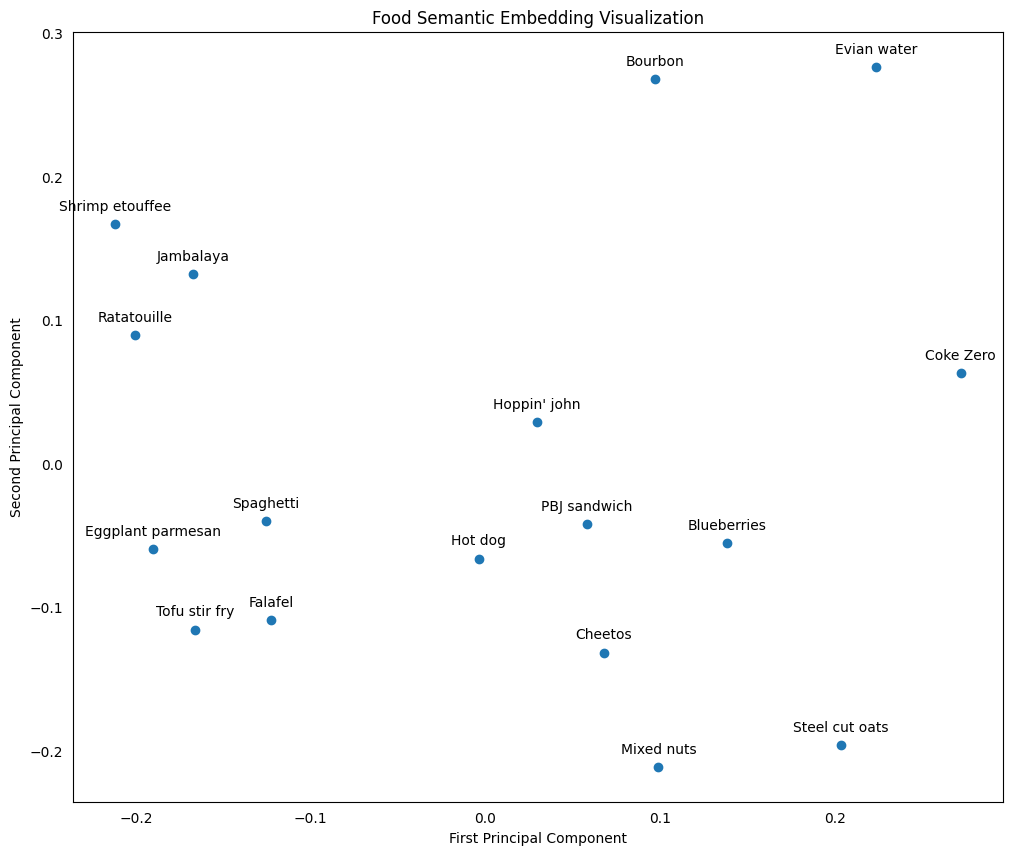

In [19]:
# reduce the number of dimensions to two using PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# plot the data
fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(x_pca[:, 0], x_pca[:, 1])

# add labels for each food
food_abbrev = foods.copy()
for i in range(len(food_abbrev)):
    ax.annotate(food_abbrev[i], (x_pca[i, 0], x_pca[i, 1]), 
                xytext=(x_pca[i, 0], x_pca[i, 1]+.0075), ha='center', va='bottom')

# title the plot
ax.set_title('Food Semantic Embedding Visualization')

# label the axes
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')

# suppress the numbers on the axes
ax.tick_params(bottom=False, top=False, left=False, right=False)

# display the plot
plt.show()

## Comparing new foods

### Finding the nearest neighbors of a food

The method of semantic embeddings also enable us to find the $k$ closest neighbors for a new type of food. To do this, we first call the `get_embedding` function to get the embedding for the new food. We then calculate the dot product between the embedding of the new food and the embeddings of the existing foods. Finally, we use the `numpy.argsort()` function to find the $k$ closest neighbors.

We will use the notion of distance for classification and clustering later in the course, when we discuss $k$-nearest neibhbors (kNN) and $k$-means.

In [20]:
# get the embedding for the new food
new_food = "Vegan Chick'n Sandwich"
new_food_embedding = get_embedding(new_food)

# calculate the dot product between the new food and the existing foods
dot_products = x @ new_food_embedding

# sort the dot products in descending order
sorted_indices = np.argsort(-dot_products)

# print the k closest neighbors
k = 5
print('The {} closest neighbors for {} are:\n'.format(k, new_food))
for i in range(k):
    neighbor = foods[sorted_indices[i]]
    print(neighbor)

The 5 closest neighbors for Vegan Chick'n Sandwich are:

PBJ sandwich
Tofu stir fry
Falafel
Eggplant parmesan
Shrimp etouffee


### Visualizing the new instance

We can now visualize the new instance as shown below.

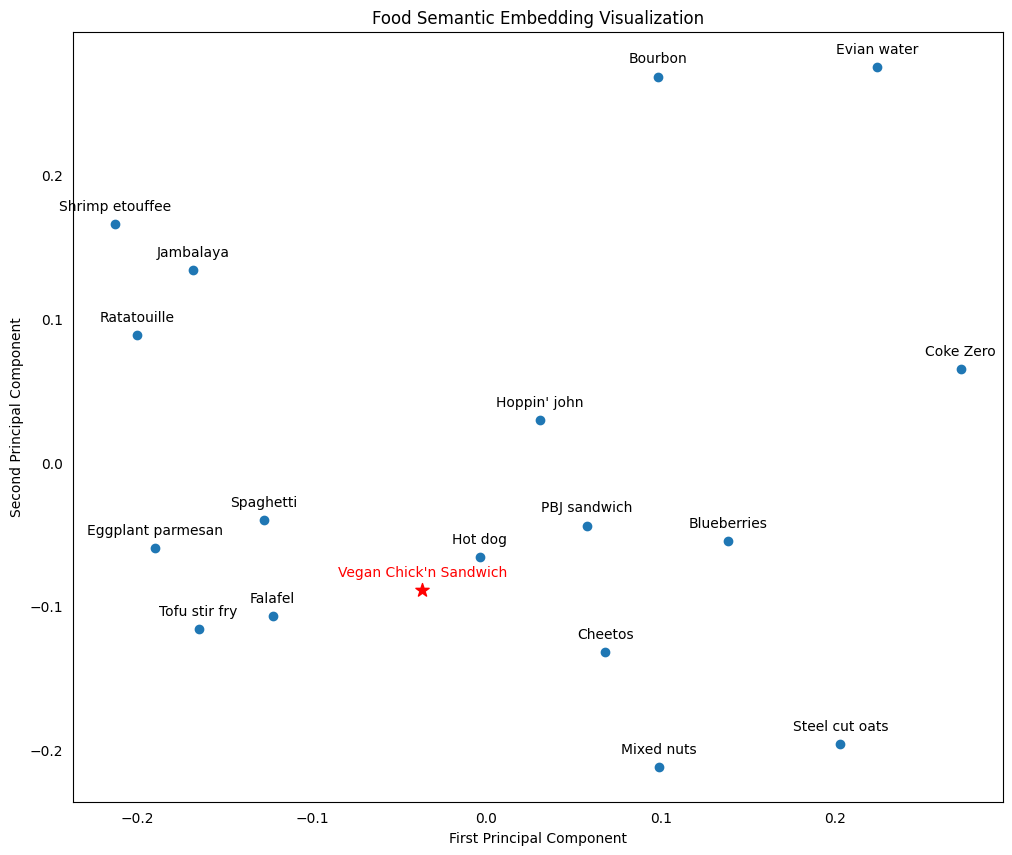

In [21]:
# reduce the number of dimensions to two using PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# plot the data
fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(x_pca[:, 0], x_pca[:, 1])

# add labels for each food
food_abbrev = foods.copy()
for i in range(len(food_abbrev)):
    ax.annotate(food_abbrev[i], (x_pca[i, 0], x_pca[i, 1]), xytext=(x_pca[i, 0], x_pca[i, 1]+.0075), ha='center', va='bottom')

# project the new food embedding onto the new PCA axes
z = np.array(new_food_embedding).reshape(1, -1)
new_food_pca = pca.transform(z)
ax.scatter(new_food_pca[:, 0], new_food_pca[:, 1], c='red', marker='*', s=100)
ax.annotate(new_food, (new_food_pca[:, 0], new_food_pca[:, 1]), 
            xytext=(new_food_pca[:, 0], new_food_pca[:, 1]+.0075), ha='center', va='bottom', color='red')

# title the plot
ax.set_title('Food Semantic Embedding Visualization')

# label the axes
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')

# suppress the numbers on the axes
ax.tick_params(bottom=False, top=False, left=False, right=False)

# display the plot
plt.show()

#### Explaining the Difference in Visualization

**Principal Component Analysis (PCA)** is a **linear** dimensionality reduction technique that projects data onto a linear subspace. In our visualization, this causes the new food "Vegan Chick'n Sandwich" to appear closer to Hot Dog than Peanut Butter and Jelly (PBJ), even though in the original embedded space, it was closer to PBJ, and Hot Dog was not even in the top 5 closest neighbors. This difference is due to the linear projection, as well as the fact that PCA depends on the distribution of the data. If the Vegan Chick'n Sandwich had been included in the original embedding space, the projection would have been different.

## Embedding Course Descriptions

Let's take a look at another examples. We have course descriptions on an external file. We will read that, compute the embeddings, and plot the results in lower dimensional space as we did for the food words.

In [22]:
def import_file(filename):
    try:
        with open(filename, 'r') as f:
            # Create a list of strings from the file
            data = f.read().split('\n\n')
            # Strip the whitespace from each line
            data = [entry.strip() for entry in data]
            # Return the list
            return data
    except FileNotFoundError:
        print('File not found!')
        return None

In [23]:
course_descriptions = import_file('course_descriptions.txt')

In [24]:
def get_titles(course_descriptions):
    titles = []
    for entry in course_descriptions:
        # Split the entry on the period
        parts = entry.split('.')
        # Get the title by taking the first part of the split
        title = parts[0]
        # Strip whitespace from the title
        title = title.strip()
        # Split the title on the space
        parts = title.split(' ')
        # Get the course code by taking the first part of the split
        course_code = parts[0] + parts[1]
        # Add the course code to the list
        titles.append(course_code)
    # Return the list of titles
    return titles

In [25]:
course_titles = get_titles(course_descriptions)
print(course_titles[:5])

['CSC170', 'CSC270', 'CSC341', 'CSC372', 'CSC362']


In [26]:
def embed_courses(courses):
    '''
    Embeds a list of courses into a single numpy matrix.
    '''
    embedding_size = 1536
    x = np.zeros((len(courses), embedding_size))
    for i, course in enumerate(courses):
        x[i,:] = get_embedding(course)
    return x

In [27]:
embeddings_file = 'course_embeddings.pickle'
try: # throws exception if pickle file does not exist
    with open(embeddings_file, 'rb') as f:
        x = pickle.load(f) 
except FileNotFoundError:
    print("Pickle file not found. Would you like to rerun the code that creates it?")
    answer = input("Entering 'yes' will recompute all course embeddings. Continue? (yes/no) ")
    if answer == "yes":
        x = embed_courses(course_descriptions)
        with open(embeddings_file, 'wb') as f:
            pickle.dump(x, f)
finally:
    print('x =')
    print(x)

x =
[[ 0.02644019  0.00961053  0.00562912 ... -0.01961857 -0.00717424 -0.02245236]
 [ 0.01062507  0.01276069  0.03424959 ... -0.00511025 -0.02057363 -0.02215213]
 [ 0.01596441  0.0020677   0.02817713 ... -0.01606936  0.00277934 -0.02233969]
 ...
 [ 0.00186954 -0.00086242 -0.00199596 ... -0.00329    -0.00571176 -0.0388812 ]
 [ 0.00854046  0.02421166 -0.00287474 ... -0.01632233 -0.01158114 -0.02596906]
 [-0.0010607  -0.00452909 -0.00255887 ... -0.01157364 -0.00977873 -0.02070259]]


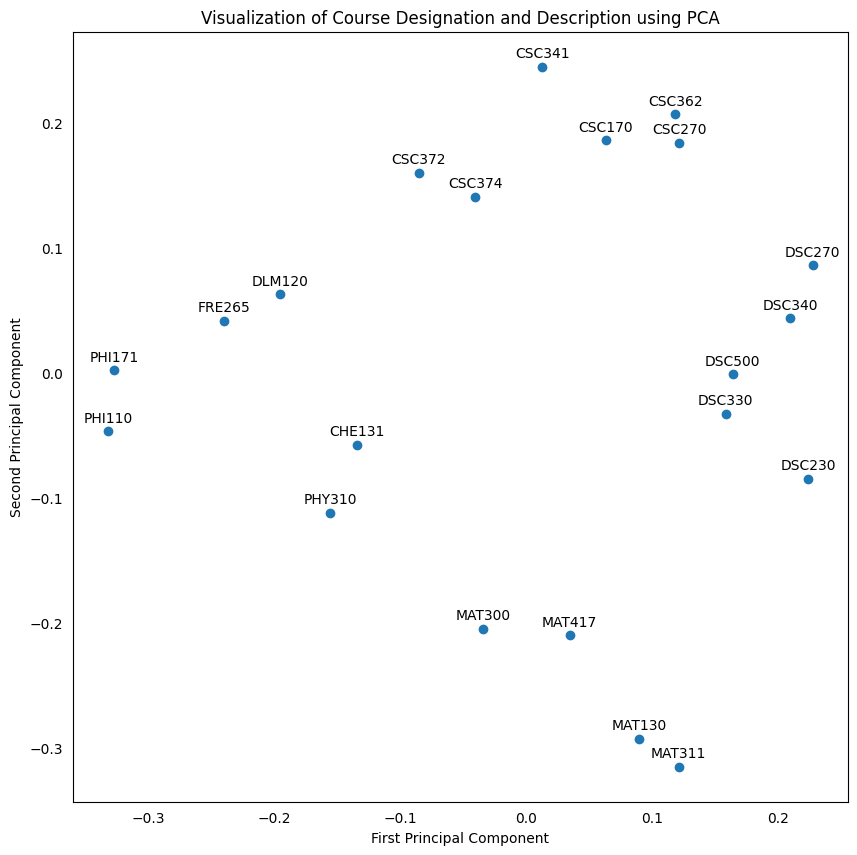

In [28]:
# reduce the number of dimensions to two using PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# plot the data
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x_pca[:, 0], x_pca[:, 1])

# add labels for each course
for i in range(len(course_descriptions)):
    ax.annotate(course_titles[i], (x_pca[i, 0], x_pca[i, 1]), 
                xytext=(x_pca[i, 0], x_pca[i, 1]+.005), ha='center', va='bottom')

# title the plot
ax.set_title('Visualization of Course Designation and Description using PCA')

# label the axes
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')

# suppress the numbers on the axes
ax.tick_params(bottom=False, top=False, left=False, right=False)

# display the plot
plt.show()

The courses are nicely grouped together by program (CSC, DSC, etc.). However, since each string starts with the course designation (e.g., DSC 305), it occurs that maybe the label has too much influence on the visualization. So we decide to strip off the course designations and embed only the descriptions from the course catalog.

In [29]:
def strip_first_eight(course_descriptions):
    for i, entry in enumerate(course_descriptions):
        # Strip off the first 8 characters of the entry
        course_descriptions[i] = entry[8:]
    # Return the modified list
    return course_descriptions

course_descriptions = strip_first_eight(course_descriptions)
xx = x.copy()

In [30]:
embeddings_file = 'course_embeddings2.pickle'
try: # throws exception if pickle file does not exist
    with open(embeddings_file, 'rb') as f:
        x = pickle.load(f) 
except FileNotFoundError:
    print("Pickle file not found. Would you like to rerun the code that creates it?")
    answer = input("Entering 'yes' will recompute all course embeddings. Continue? (yes/no) ")
    if answer == "yes":
        x = embed_courses(course_descriptions)
        with open(embeddings_file, 'wb') as f:
            pickle.dump(x, f)
finally:
    print('x =')
    print(x)

x =
[[ 0.02005099  0.01150059 -0.00243134 ... -0.02386962 -0.02130259 -0.01319279]
 [ 0.00781849  0.00404519  0.01761315 ... -0.00769912 -0.02632688 -0.01709589]
 [ 0.01026044 -0.00561989  0.02358215 ... -0.01595492 -0.00147388 -0.01470966]
 ...
 [-0.00140379  0.00038188  0.00369836 ...  0.00164628 -0.01623188 -0.0429419 ]
 [ 0.01515191  0.02130977 -0.00386144 ... -0.02573014 -0.01324834 -0.02518079]
 [-0.00137447  0.01243448 -0.0008454  ... -0.01490082 -0.01230603 -0.00973692]]


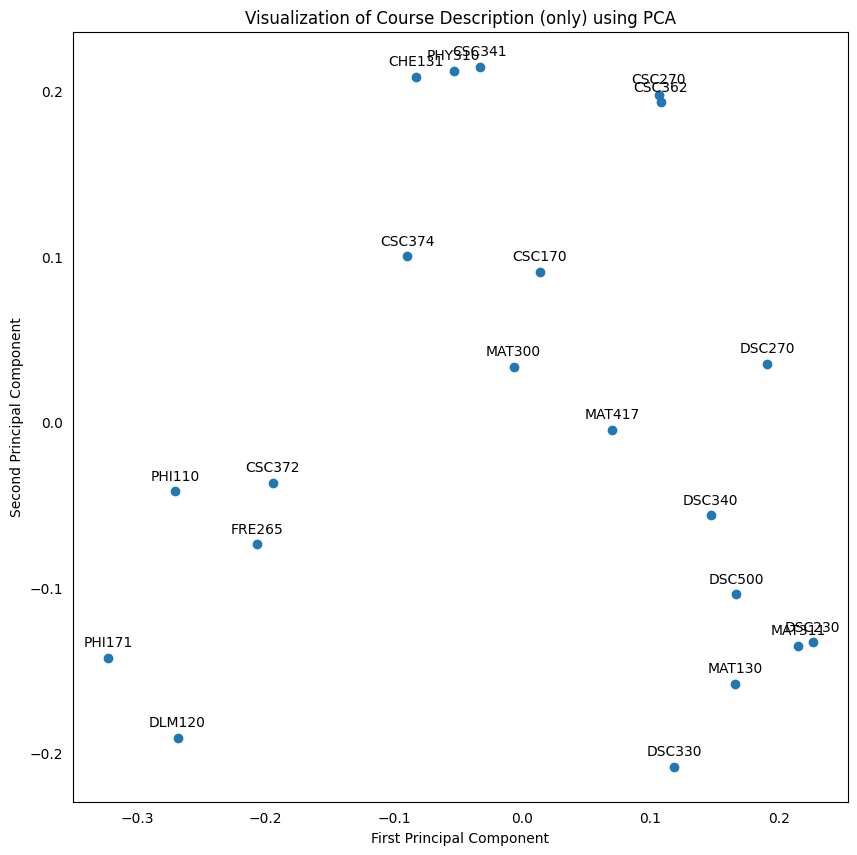

In [31]:
# reduce the number of dimensions to two using PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# plot the data
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x_pca[:, 0], x_pca[:, 1])

# add labels for each course
for i in range(len(course_descriptions)):
    ax.annotate(course_titles[i], (x_pca[i, 0], x_pca[i, 1]), 
                xytext=(x_pca[i, 0], x_pca[i, 1]+.005), ha='center', va='bottom')

# title the plot
ax.set_title('Visualization of Course Description (only) using PCA')

# label the axes
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')

# suppress the numbers on the axes
ax.tick_params(bottom=False, top=False, left=False, right=False)

# display the plot
plt.show()

### Visualizing Data with t-SNE

The **t-Distributed Stochastic Neighbor Embedding (t-SNE)** algorithm is an effective way to visualize high-dimensional data by reducing its dimensionality to two or three dimensions. It is a **nonlinear** dimensional reduction technique that is well-suited for embedding objects in a **low-dimensional space while preserving the local structure of the data**. t-SNE can also reveal **global structure**, allowing us to better understand complex datasets. 

We now show how to use t-SNE rather than PCA to visualize embeddings so we can explore the high-dimensional space of the embeddings and better understand the relationships between different data points.

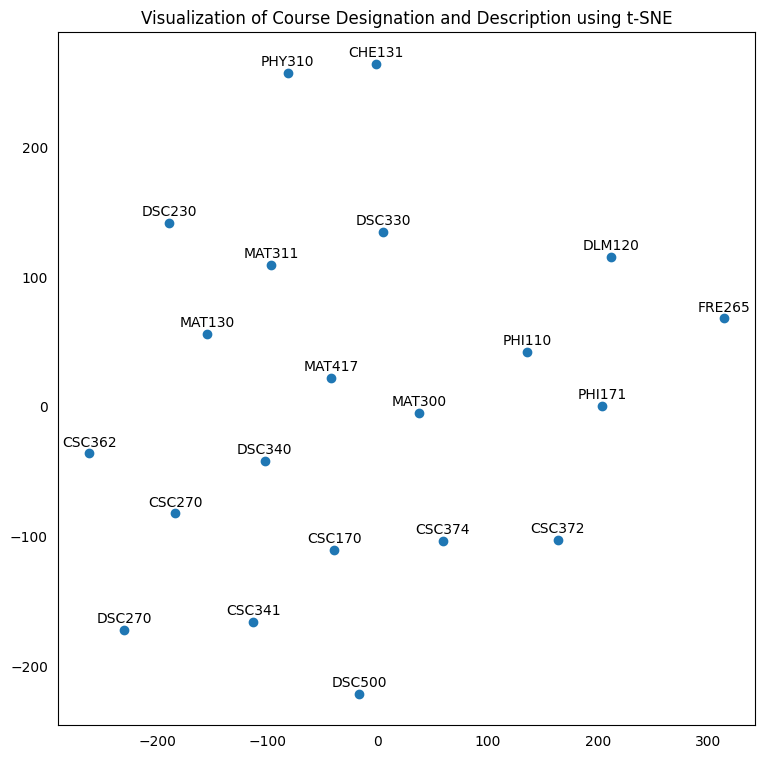

In [32]:
# Create a t-SNE model and transform the data
tsne = TSNE(n_components=2, perplexity=15, random_state=0,  ## change to 2 for comparison
            init='random', learning_rate=200)
vis_dims = tsne.fit_transform(x)
vis_dims.shape

# plot the data
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(vis_dims[:, 0], vis_dims[:, 1])

# add labels for each course
for i in range(len(course_titles)):
    ax.annotate(course_titles[i], (vis_dims[i, 0], vis_dims[i, 1]), 
                xytext=(vis_dims[i, 0], vis_dims[i, 1]+3), ha='center', va='bottom')

# title the plot
ax.set_title('Visualization of Course Designation and Description using t-SNE')

# suppress the numbers on the axes
ax.tick_params(bottom=False, top=False, left=False, right=False)

# display the plot
plt.show()

### Finding similar courses

We now look for the courses most similar to CSC 372.

In [33]:
# specify the course for comparison
course_id = 'CSC372'

# use matrix multiplication to compute the similarity matrix
similarity_matrix = np.round(x @ x.T, 2)

# find the index of the course in course_titles
i = course_titles.index(course_id)

# get the row of the distance matrix corresponding to the course
row = similarity_matrix[i,:]

# find the indices of the largest items in the row
indices = np.argsort(-row)[1:6]

# get the corresponding courses
similar_courses = [(course_titles[index], row[index]) for index in indices]

# print the courses
print('Courses most similar to', course_id + ':')
for course, similarity in similar_courses:
    percent = similarity * 100
    print(f'  {course}    Score: {percent:.1f}')    

Courses most similar to CSC372:
  PHI110    Score: 83.0
  CSC374    Score: 82.0
  CSC170    Score: 81.0
  PHI171    Score: 81.0
  DSC340    Score: 81.0


We discover that the course most similar to CSC 372 (Artificial Intelligence) is DSC 395 (Machine Learning Theory and Practice). It is intuitive that these two courses overlap in subject matter, yet in both t-SNE visualizations, the two courses appear far apart. This highlights the difficulty of visualizing high-dimensional data, and serves as a reminder to be cautious when relying on such visualizations, no matter the algorithm used.

## Course recommendation

We close with a simple application of semantic distance: a **recommender system**. A recommender system is a type of information filtering system that is used to predict the preferences or ratings that a user would give to an item. Recommender systems leverage the similarity between different users or items to make recommendations, such as suggesting movies, courses, books, or products.

Here, given a statement elicited from a user, we will use semantic distance to recommend a list of relevant courses. To do this, we must first obtain an embedding for the interest statement, and then compute the similarity between this embedding and the embeddings of each course title.

In [34]:
#interest = "anything but physics. I hate physics"
#interest = ("I'm looking for a course that will help me learn to solve problems "
#            "in the real world. I love computers and coding.")
#interest = ("I'm excited and a bit scared by the potential of GAI. "
#            "I'm interested in learning about AI Alignment and considering "
#            "the implications of its development. The singularity is near!")
# interest = "My hero is Einstein. I want to get a Ph.D. in physics."
# interest = "I want to learn to program in advanced languages like Scala and Prolog."
#interest = "Financial analytics and predictive analytics problems."
# interest = "I want to know how to prove that the square root of 2 is irrational."
interest = "I'm majoring in French and want to live in Paris one day."
# interest = "I want to get a Ph.D. in chemical biology and work in the pharmaceutical industry."
# interest = "I want to get a Ph.D. in reinforcement learning. I'm told a lot of heavy calculus and statistics is involved."

# Find the top 5 courses for this student.

# Get the embedding for the user's description
prompt = "My interest is: " + interest + " Please recommend a suitable course for me."
print(prompt + '\n')
interest_embedding = get_embedding(prompt)

# Create an empty list for the similarities
similarities = []
# Iterate through all courses
for i, course in enumerate(course_titles):
    # Get the embedding for the course
    course_embedding = x[i,:]
    # Compute the cosine similarity
    similarity = interest_embedding @ course_embedding
    # Add the similarity to the list
    similarities.append((course, similarity))
# Sort the list by similarity
similarities = sorted(similarities, key=lambda x: x[1], reverse=True)
# Return the top 5 courses
top_courses = similarities[:5]

# Print the results
print('Top 5 courses for this student:')
for course, similarity in top_courses:
    percent = similarity * 100
    print(f'  {course}    Score: {percent:.1f}')  

My interest is: I'm majoring in French and want to live in Paris one day. Please recommend a suitable course for me.

Top 5 courses for this student:
  FRE265    Score: 77.5
  PHI110    Score: 76.4
  CSC170    Score: 75.6
  MAT300    Score: 74.9
  DSC340    Score: 74.7


In [35]:
embeddings_file = 'course_embeddings.pickle'
try: # throws exception if pickle file does not exist
    with open(embeddings_file, 'rb') as f:
        x = pickle.load(f) 
except FileNotFoundError:
    print("Pickle file not found. Would you like to rerun the code that creates it?")
    answer = input("Entering 'yes' will recompute all course embeddings. Continue? (yes/no) ")
    if answer == "yes":
        x = embed_courses(course_descriptions)
        with open(embeddings_file, 'wb') as f:
            pickle.dump(x, f)
finally:
    print('x =')
    print(x)

x =
[[ 0.02644019  0.00961053  0.00562912 ... -0.01961857 -0.00717424 -0.02245236]
 [ 0.01062507  0.01276069  0.03424959 ... -0.00511025 -0.02057363 -0.02215213]
 [ 0.01596441  0.0020677   0.02817713 ... -0.01606936  0.00277934 -0.02233969]
 ...
 [ 0.00186954 -0.00086242 -0.00199596 ... -0.00329    -0.00571176 -0.0388812 ]
 [ 0.00854046  0.02421166 -0.00287474 ... -0.01632233 -0.01158114 -0.02596906]
 [-0.0010607  -0.00452909 -0.00255887 ... -0.01157364 -0.00977873 -0.02070259]]


### Collaborative filtering

We note that **collaborative filtering** is another approach to building a recommender system that uses the **similarity between users** to recommend products. It works by comparing the preferences of each user to the preferences of other users, and then making recommendations based on what similar users have liked. This type of recommender system can be used to recommend courses, movies, books, and other products. We probably won't have an opportunity to discuss collaborative filtering in this course, but it would make an interesting final project.

## Conclusion

In this tutorial we introduced the concept of semantic embeddings. We learned how to embed text in high dimensional space and measure the similarity of documents using not just the words they contain, but also the context and relationships between those words. We saw how to use NumPy to calculate the semantic distance between a list of phrases, and how to use PCA or t-SNE and Matplotlib to visualize the embeddings. Finally, we used the semantic distance to build a simple course recommender system.